# Insurance Claims Fraud Analysis

## Overview

This project analyzes an insurance claims dataset to identify patterns associated with reported fraud. The analysis uses Python and pandas for data cleaning and exploratory analysis, followed by machine learning models to evaluate whether claim characteristics can help predict fraud.

## Objectives

- Clean and prepare the insurance claims data
- Explore patterns in reported fraud
- Compare fraud rates across different claim characteristics
- Build machine learning models to predict fraudulent claims
- Identify the features that contribute most to model predictions

## 1. Import Libraries and Load Data

In [113]:
import pandas as pd

df = pd.read_csv("insurance_claims_for_project.csv")

df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [115]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [116]:
df.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 '_c39']

## 2. Data Cleaning

The dataset was checked for missing values and unnecessary columns before analysis. A fully null column was removed, and missing values in `authorities_contacted` were labeled as `Unknown` so that the affected records could be retained.

In [117]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [118]:
df["authorities_contacted"].value_counts(dropna=False)

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
NaN           91
Name: count, dtype: int64

In [119]:
# Remove the completely empty column
df = df.drop(columns=["_c39"])

# Check missing values again
df.isnull().sum()

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [120]:
df.shape

(1000, 39)

In [121]:
df["authorities_contacted"] = df["authorities_contacted"].fillna("Unknown")

In [122]:
df.isnull().sum()

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

In [123]:
df["authorities_contacted"].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Unknown       91
Name: count, dtype: int64

## 3. Exploratory Data Analysis

This section provides an overview of the dataset and the distribution of reported fraudulent claims. The goal is to understand the overall fraud rate before examining which claim characteristics are associated with fraud.

In [124]:
df["fraud_reported"].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [125]:
df["fraud_reported"].value_counts(normalize=True) * 100

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

In [126]:
df["incident_type"].value_counts()

incident_type
Multi-vehicle Collision     419
Single Vehicle Collision    403
Vehicle Theft                94
Parked Car                   84
Name: count, dtype: int64

## 4. Fraud Analysis by Incident Characteristics

This section examines how reported fraud varies across different incident characteristics. Fraud rates are compared across incident type, incident severity, number of vehicles involved, policy state, claim amount, and authorities contacted to identify patterns that may be useful for further analysis and modeling.

In [127]:
pd.crosstab(
    df["incident_type"],
    df["fraud_reported"],
    normalize="index"
) * 100

fraud_reported,N,Y
incident_type,,
Multi-vehicle Collision,72.792363,27.207637
Parked Car,90.476190,9.523810
Single Vehicle Collision,70.967742,29.032258
Vehicle Theft,91.489362,8.510638


In [128]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: title={'center': 'Fraud Rate by Incident Type'}, xlabel='Incident Type', ylabel='Fraud Rate (%)'>

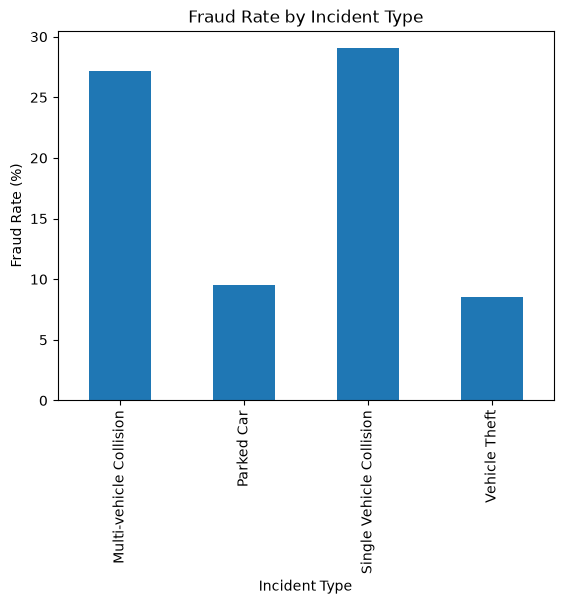

In [129]:
fraud_by_incident = pd.crosstab(
    df["incident_type"],
    df["fraud_reported"],
    normalize="index"
) * 100

fraud_by_incident["Y"].plot(
    kind="bar",
    title="Fraud Rate by Incident Type",
    ylabel="Fraud Rate (%)",
    xlabel="Incident Type"
)

### Fraud Rate by Incident Severity

Fraud rates differed substantially by incident severity. Major damage claims had the highest fraud rate at approximately 60%, while total loss, minor damage, and trivial damage claims had much lower fraud rates.

The large difference in fraud rates makes incident severity an important variable to consider when building a fraud prediction model.

In [130]:
import pandas as pd

In [131]:
df = pd.read_csv("insurance_claims_for_project.csv")

In [132]:
df = df.drop(columns=["_c39"])

In [133]:
df["authorities_contacted"] = df["authorities_contacted"].fillna("Unknown")

In [134]:
df.isnull().sum()

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

In [135]:
df["fraud_reported"].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [136]:
df["fraud_reported"].value_counts(normalize=True) * 100

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

In [137]:
df["incident_type"].value_counts()

incident_type
Multi-vehicle Collision     419
Single Vehicle Collision    403
Vehicle Theft                94
Parked Car                   84
Name: count, dtype: int64

In [138]:
fraud_by_incident = pd.crosstab(
    df["incident_type"],
    df["fraud_reported"],
    normalize="index"
) * 100

In [139]:
fraud_by_incident

fraud_reported,N,Y
incident_type,,
Multi-vehicle Collision,72.792363,27.207637
Parked Car,90.476190,9.523810
Single Vehicle Collision,70.967742,29.032258
Vehicle Theft,91.489362,8.510638


<Axes: title={'center': 'Fraud Rate by Incident Type'}, xlabel='Incident Type', ylabel='Fraud Rate (%)'>

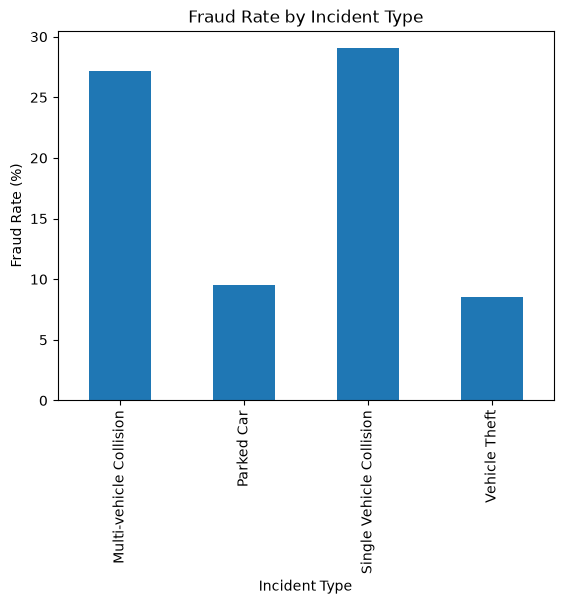

In [140]:
fraud_by_incident["Y"].plot(
    kind="bar",
    title="Fraud Rate by Incident Type",
    ylabel="Fraud Rate (%)",
    xlabel="Incident Type"
)

In [141]:
fraud_by_severity = pd.crosstab(
    df["incident_severity"],
    df["fraud_reported"],
    normalize="index"
) * 100

fraud_by_severity

fraud_reported,N,Y
incident_severity,,
Major Damage,39.492754,60.507246
Minor Damage,89.265537,10.734463
Total Loss,87.142857,12.857143
Trivial Damage,93.333333,6.666667


<Axes: title={'center': 'Fraud Rate by Incident Severity'}, xlabel='Incident Severity', ylabel='Fraud Rate (%)'>

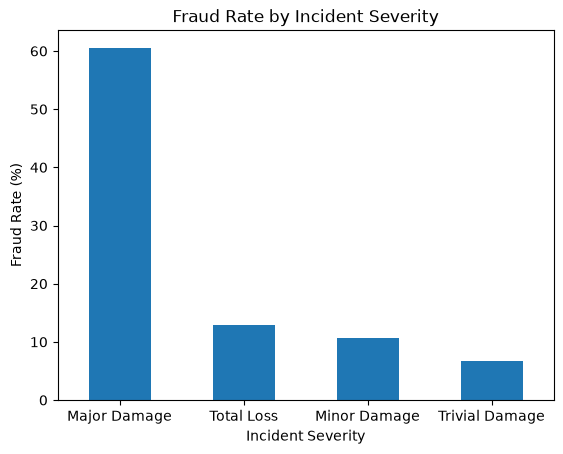

In [142]:
fraud_by_severity["Y"].sort_values(ascending=False).plot(
    kind="bar",
    title="Fraud Rate by Incident Severity",
    ylabel="Fraud Rate (%)",
    xlabel="Incident Severity",
    rot=0
)

### Fraud Rate by Incident Severity

Fraud rates differed substantially by incident severity. Major damage claims had the highest fraud rate at approximately 60%, while total loss, minor damage, and trivial damage claims had much lower fraud rates.

The large difference in fraud rates makes incident severity an important variable to consider when building a fraud prediction model.

In [143]:
df["incident_severity"].value_counts()

incident_severity
Minor Damage      354
Total Loss        280
Major Damage      276
Trivial Damage     90
Name: count, dtype: int64

In [144]:
severity_fraud_counts = pd.crosstab(
    df["incident_severity"],
    df["fraud_reported"]
)

severity_fraud_counts

fraud_reported,N,Y
incident_severity,,
Major Damage,109,167
Minor Damage,316,38
Total Loss,244,36
Trivial Damage,84,6


In [145]:
fraud_by_vehicles = pd.crosstab(
    df["number_of_vehicles_involved"],
    df["fraud_reported"],
    normalize="index"
) * 100

fraud_by_vehicles

fraud_reported,N,Y
number_of_vehicles_involved,,
1,77.108434,22.891566
2,70.000000,30.000000
3,73.743017,26.256983
4,64.516129,35.483871


<Axes: title={'center': 'Fraud Rate by Number of Vehicles Involved'}, xlabel='Number of Vehicles Involved', ylabel='Fraud Rate (%)'>

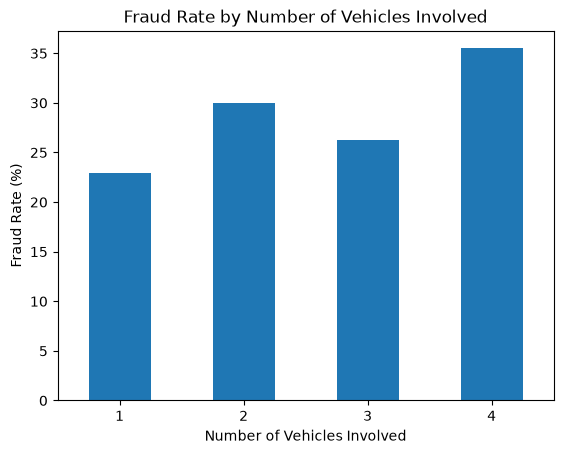

In [146]:
fraud_by_vehicles["Y"].sort_index().plot(
    kind="bar",
    title="Fraud Rate by Number of Vehicles Involved",
    ylabel="Fraud Rate (%)",
    xlabel="Number of Vehicles Involved",
    rot=0
)

### Fraud Rate by Number of Vehicles Involved

The fraud rate varied across the number of vehicles involved in an incident. Claims involving four vehicles had the highest observed fraud rate, followed by two vehicles, three vehicles, and one vehicle.

Because some vehicle-count categories may contain fewer observations than others, these differences should be interpreted with caution.

In [147]:
fraud_by_state = pd.crosstab(
    df["policy_state"],
    df["fraud_reported"],
    normalize="index"
) * 100

fraud_by_state

fraud_reported,N,Y
policy_state,,
IL,77.218935,22.781065
IN,74.516129,25.483871
OH,74.147727,25.852273


<Axes: title={'center': 'Fraud Rate by Policy State'}, xlabel='Policy State', ylabel='Fraud Rate (%)'>

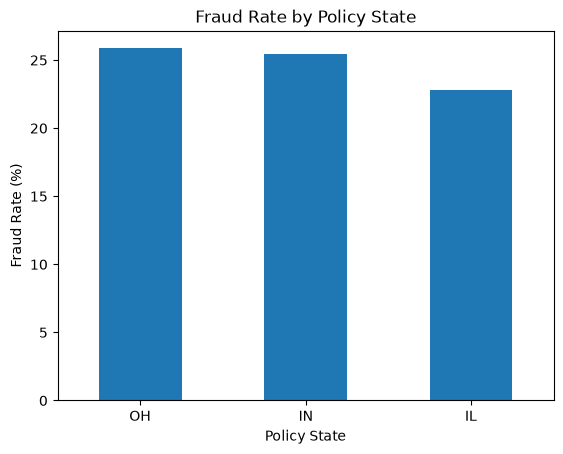

In [148]:
fraud_by_state["Y"].sort_values(ascending=False).plot(
    kind="bar",
    title="Fraud Rate by Policy State",
    ylabel="Fraud Rate (%)",
    xlabel="Policy State",
    rot=0
)

### Fraud Rate by Policy State

Fraud rates were relatively similar across the three policy states. Ohio and Indiana had fraud rates of approximately 26%, while Illinois had a slightly lower rate of approximately 23%.

The relatively small differences suggest that policy state was less informative in this dataset than some of the other incident characteristics examined.

In [149]:
df.groupby("fraud_reported")["total_claim_amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
fraud_reported,,,,,
N,753,50288.605578,56520.0,100,114920
Y,247,60302.105263,61290.0,2860,112320


<Axes: title={'center': 'total_claim_amount'}, xlabel='fraud_reported'>

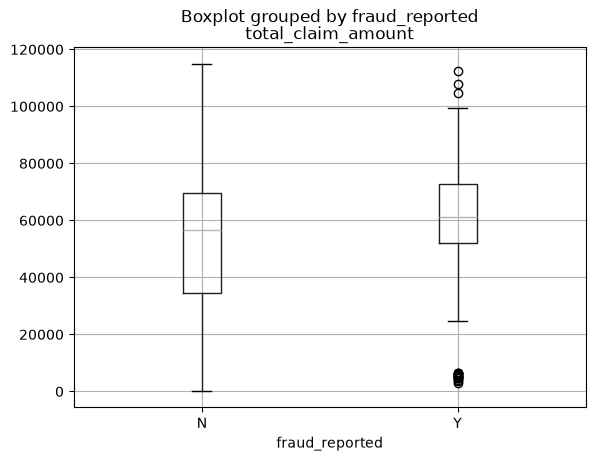

In [150]:
df.boxplot(
    column="total_claim_amount",
    by="fraud_reported"
)


### Claim Amount and Reported Fraud

The distribution of total claim amounts was compared between fraudulent and non-fraudulent claims. Fraudulent claims had a somewhat higher median claim amount, although there was substantial overlap between the two groups.

This suggests that claim amount may contain some predictive information, but it does not clearly separate fraudulent claims from non-fraudulent claims on its own.

In [151]:
fraud_by_authority = pd.crosstab(
    df["authorities_contacted"],
    df["fraud_reported"],
    normalize="index"
) * 100

fraud_by_authority

fraud_reported,N,Y
authorities_contacted,,
Ambulance,70.918367,29.081633
Fire,73.094170,26.905830
Other,68.181818,31.818182
Police,79.109589,20.890411
Unknown,93.406593,6.593407


<Axes: title={'center': 'Fraud Rate by Authority Contacted'}, xlabel='Authority Contacted', ylabel='Fraud Rate (%)'>

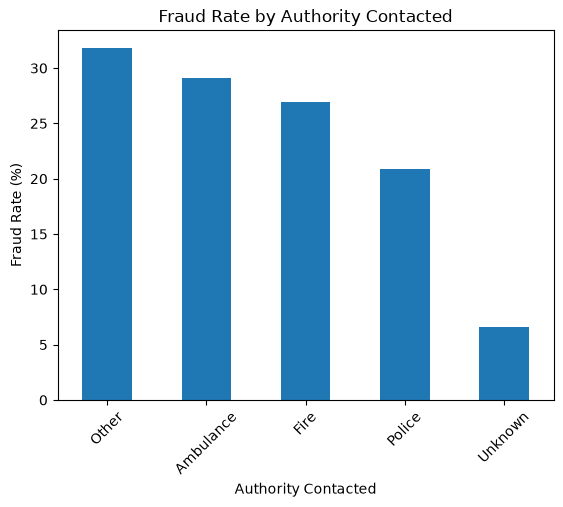

In [152]:
fraud_by_authority["Y"].sort_values(ascending=False).plot(
    kind="bar",
    title="Fraud Rate by Authority Contacted",
    ylabel="Fraud Rate (%)",
    xlabel="Authority Contacted",
    rot=45
)

### Fraud Rate by Authorities Contacted

Fraud rates varied across the authority contacted during an incident. The highest observed rates were among claims associated with "Other" and "Ambulance", while claims associated with "Police" had a lower observed rate.

Missing values in this variable were labeled as "Unknown" during data cleaning. Therefore, the "Unknown" category should not be interpreted as a meaningful type of authority contact.

In [153]:
df.shape

(1000, 39)

## 5. Machine Learning

This section uses machine learning to predict whether an insurance claim was reported as fraudulent. A subset of relevant claim characteristics is used as input features, while the reported fraud indicator is used as the target variable.

Categorical variables are converted into numerical features using one-hot encoding, while numerical variables are passed through directly. The data is split into training and testing sets so that model performance can be evaluated on previously unseen claims.

In [154]:
df["fraud_reported"].value_counts()

df["fraud"] = df["fraud_reported"].map({"N": 0, "Y": 1})

df["fraud"].value_counts()

model_df = df.drop(columns=[
    "fraud_reported",
    "fraud",
    "policy_number",
    "policy_bind_date",
    "incident_date",
    "incident_location",
    "insured_zip"
])

model_df.head()

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,1,2,YES,71610,6510,13020,52080,Saab,92x,2004
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,0,0,?,5070,780,780,3510,Mercedes,E400,2007
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,0,1,NO,6500,1300,650,4550,Accura,RSX,2009


In [155]:
X = model_df
y = df["fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 33)
y shape: (1000,)


In [156]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']

Numerical columns:
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']


C:\Users\prade\AppData\Local\Temp\ipykernel_10912\3500151795.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [157]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 33)
Testing set: (200, 33)


In [159]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("numerical", "passthrough", numerical_columns)
    ]
)

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [161]:
model.fit(X_train, y_train)

c:\Users\prade\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['months_as_customer','age','policy_state',...,'auto_make','auto_model', 'auto_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [162]:
y_pred = model.predict(X_test)

y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## 6. Model Evaluation

The models are evaluated using accuracy, precision, recall, and F1-score. Because fraud detection involves identifying the fraudulent class, precision and recall are particularly useful alongside overall accuracy.

The test set contains claims that were not used to train the models, allowing their performance to be evaluated on unseen data.

In [163]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 75.00%


In [164]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[150   1]
 [ 49   0]]


In [165]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Not Fraud       0.75      0.99      0.86       151
       Fraud       0.00      0.00      0.00        49

    accuracy                           0.75       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.57      0.75      0.65       200



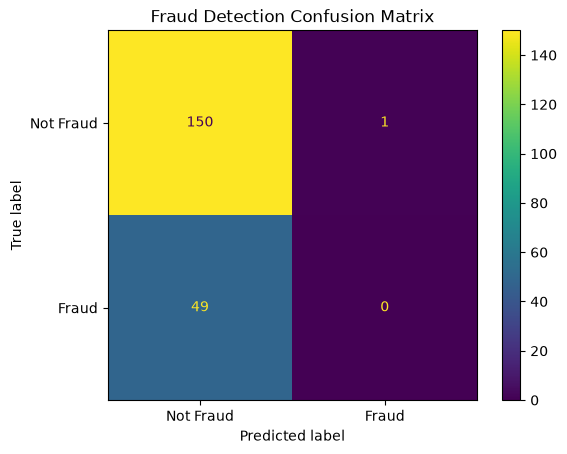

In [166]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Fraud", "Fraud"]
)

plt.title("Fraud Detection Confusion Matrix")
plt.show()

## 7. Feature Importance

Feature importance from the Random Forest model was examined to identify which variables contributed most to the model's predictions. Because categorical variables were one-hot encoded, individual categories such as "Major Damage" appear as separate features.

In [167]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

print("Random Forest Results")
print("---------------------")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Not Fraud", "Fraud"]
    )
)

Random Forest Results
---------------------
              precision    recall  f1-score   support

   Not Fraud       0.91      0.85      0.88       151
       Fraud       0.62      0.73      0.67        49

    accuracy                           0.82       200
   macro avg       0.76      0.79      0.78       200
weighted avg       0.84      0.82      0.83       200



In [168]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750,0.00000,0.000000,0.000000
1,Random Forest,0.825,0.62069,0.734694,0.672897


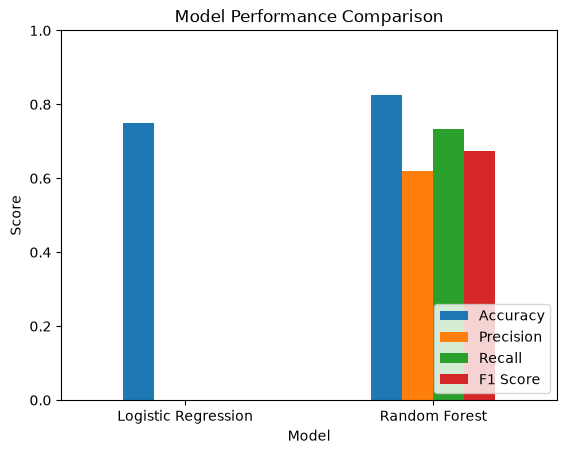

In [169]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    ylim=(0, 1),
    title="Model Performance Comparison",
    ylabel="Score",
    xlabel="Model",
    rot=0
)

plt.legend(loc="lower right")
plt.show()

### Model Performance

The Logistic Regression and Random Forest models were compared using their classification metrics. The Random Forest model achieved approximately 82.5% accuracy on the test set, with a fraud recall of approximately 73%.

This means the model identified a substantial portion of the fraudulent claims in the test set, while still producing some incorrect classifications. Model performance should be interpreted using multiple metrics rather than accuracy alone.

In [170]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['months_as_customer','age','policy_state',...,'auto_make','auto_model', 'auto_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [171]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
63,categorical__incident_severity_Major Damage,0.119205
34,categorical__insured_hobbies_chess,0.046410
64,categorical__incident_severity_Minor Damage,0.044739
156,numerical__total_claim_amount,0.034842
158,numerical__property_claim,0.034692
159,numerical__vehicle_claim,0.033019
35,categorical__insured_hobbies_cross-fit,0.032263
157,numerical__injury_claim,0.031088
148,numerical__policy_annual_premium,0.028917
65,categorical__incident_severity_Total Loss,0.027345


<Axes: title={'center': 'Top 10 Features by Random Forest Importance'}, xlabel='Feature Importance', ylabel='Feature'>

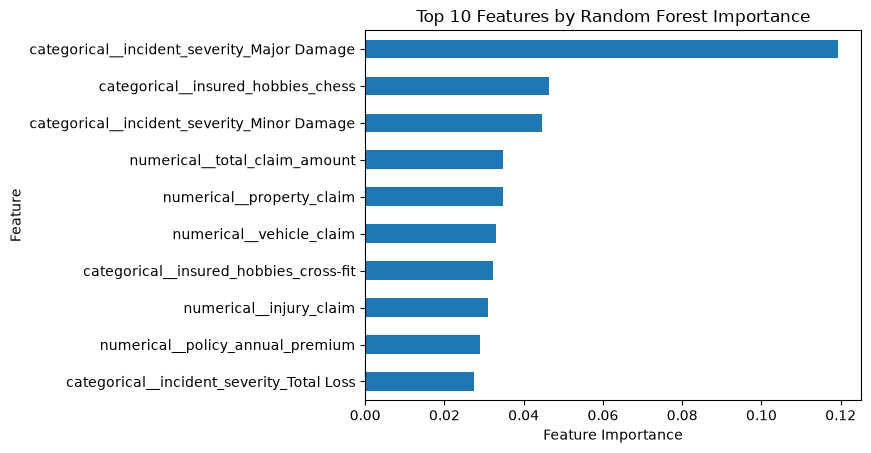

In [172]:
top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

top_features.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False,
    title="Top 10 Features by Random Forest Importance",
    xlabel="Feature Importance",
    ylabel="Feature"
)

### Top Features

Incident severity was among the most important features in the Random Forest model. In particular, the "Major Damage" category had the highest individual feature importance.

This finding is consistent with the exploratory analysis, which showed a substantially higher fraud rate among major damage claims. Other features, including insured hobbies, claim amounts, property and vehicle claim values, and policy information, also contributed to the model's predictions.

Feature importance indicates how useful a feature was to the model's predictions. It does not mean that the feature causes fraud.